### Load Different Forecast Lengths

Notebook contents 
* in the previous notebook, `7_process..` we created netcdfs from the grib files for all the different forecasts
* in this notebook, we are going to load the netcdfs and compare them as a timeseries

created by Cassie Lumbrazo\
last updated: April 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker
import seaborn as sns 
sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime
import scipy
import rioxarray
import rasterio 
import cfgrib

In [13]:
import geopandas as gpd
from shapely.geometry import Point

In [2]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [3]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

### Load the HRRR-AK Datasets

In [16]:
filepath = "/hdd/snow_hydrology/hrrrak/small_juneau_domain/netcdf/"

filename_f123 = "hrrrak_merged_grib_f123_WY2024.nc" # this one has a different data structure and datetime range 
filename_f567 = "hrrrak_merged_grib_f567_WY2024_test1.nc"
filename_f678 = "hrrrak_merged_grib_f678_WY2024_test1.nc"
filename_f6to11 = "hrrrak_merged_grib_f6to11_WY2024_test1.nc"
filename_f6to29 = "hrrrak_merged_grib_f6to29_WY2024_test1.nc"

# load data
ds_f123 = xr.open_dataset(filepath + filename_f123)
ds_f567 = xr.open_dataset(filepath + filename_f567)
ds_f678 = xr.open_dataset(filepath + filename_f678)
ds_f6to11 = xr.open_dataset(filepath + filename_f6to11)
ds_f6to29 = xr.open_dataset(filepath + filename_f6to29)

# assign crs EPSG: 4326 
ds_f123.rio.write_crs("EPSG:4326", inplace=True)
ds_f567.rio.write_crs("EPSG:4326", inplace=True)
ds_f678.rio.write_crs("EPSG:4326", inplace=True)
ds_f6to11.rio.write_crs("EPSG:4326", inplace=True)
ds_f6to29.rio.write_crs("EPSG:4326", inplace=True)

<xarray.Dataset> Size: 289MB
Dimensions:                  (time: 3311, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T06:00:00 ....
    step                     (time) timedelta64[ns] 26kB ...
    valid_time               (time) datetime64[ns] 26kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 6MB ...
    temp                     (time, y, x) float32 6MB ...
    d2m                      (time, y, x) float32 6MB ...
    sh2                      (time, y, x) float32 6MB ...
    rh                       (time, y, x) float32 6MB ...
    u10                      (time, y, x) float32 6MB ...
    ...                       ...
    lai                      (time, y, x) float32 6MB ...
    vgtyp                    (time, y, x) float32 6MB ...
    cloud_total              (time, y, x) float32 6MB ...
    cloud_high               (time, y, x) float32 6MB ...
    cloud_low                (time, y, x) float32 6MB ...
    wind                     (time, y, x) float32 6MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

Since there were a few forecasts missing variables, the datetimes are all different lengths.\
Might need to do something there...

In [17]:
# clip ds_f123 to the same time range as ds_f567
ds_f123 = ds_f123.sel(time=slice("2023-10-01", "2024-02-15"))

In [18]:
def convert_hrrr_ak_to_utm(ds):
    """
    Convert an HRRR-AK xarray Dataset from its native longitude/latitude grid to UTM (EPSG:32608).
    
    This function assumes the input dataset `ds` has 2D 'longitude' and 'latitude' coordinates
    (as is typical for HRRR-AK data). It extracts 1D coordinates, sets spatial dimensions,
    and reprojects to UTM Zone 8N (EPSG:32608), which is suitable for Alaska.
    
    Parameters:
    - ds (xarray.Dataset): The input HRRR-AK dataset with 'longitude' and 'latitude' dims.
    
    Returns:
    - xarray.Dataset: The reprojected dataset in UTM coordinates.
    
    Notes:
    - This modifies a copy of the dataset to avoid altering the original.
    - Ensure rioxarray is installed and configured (e.g., with GDAL for reprojection).
    - If the dataset lacks 'longitude'/'latitude' or has a different structure, this may fail.
    """
    # Work on a copy to avoid modifying the original dataset
    ds = ds.copy()
    
    # Step 1: Rename dimensions if needed and set spatial dims
    ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    
    # Step 2: Extract 1D x and y coordinates from the 2D grid
    x_1d = ds['x'].isel(y=0)  # Same x values across rows
    y_1d = ds['y'].isel(x=0)  # Same y values down columns
    
    # Step 3: Assign 1D coords to the dataset
    ds = ds.assign_coords(x=x_1d, y=y_1d)
    
    # Step 4: Drop the 2D coords from the coordinate system
    ds = ds.drop_vars(['x', 'y'])  # Remove old 2D variables
    ds = ds.set_coords([])         # Ensure no unexpected spatial coords
    
    # Step 5: Reassign the cleaned 1D coords
    ds = ds.assign_coords({'x': x_1d, 'y': y_1d})
    
    # Step 6: Reproject to UTM (EPSG:32608 for Alaska)
    ds_utm = ds.rio.reproject("EPSG:32608")
    
    return ds_utm

Convert to UTM, 

In [19]:
ds_f123 = convert_hrrr_ak_to_utm(ds_f123)
ds_f567 = convert_hrrr_ak_to_utm(ds_f567)
ds_f678 = convert_hrrr_ak_to_utm(ds_f678)
ds_f6to11 = convert_hrrr_ak_to_utm(ds_f6to11)
ds_f6to29 = convert_hrrr_ak_to_utm(ds_f6to29)

Now, select the point (powder patch) from the `ds` 

In [20]:
def select_point_from_utm_ds(ds_utm, lat, lon):
    """
    Select a single point from a UTM-projected xarray Dataset (e.g., from HRRR-AK data) 
    based on input latitude and longitude in EPSG:4326 (WGS84).
    
    This function converts the lat/lon to UTM coordinates (EPSG:32608), then selects 
    the nearest grid cell in the dataset using xarray's .sel() method.
    
    Parameters:
    - ds_utm (xarray.Dataset): The input dataset in UTM coordinates (e.g., output from convert_hrrr_ak_to_utm).
    - lat (float): Latitude of the point in degrees (EPSG:4326).
    - lon (float): Longitude of the point in degrees (EPSG:4326).
    
    Returns:
    - xarray.Dataset: A new dataset (ds_point) containing data for the nearest grid cell to the specified point.
    
    Notes:
    - Assumes ds_utm has 'x' and 'y' dimensions in UTM meters.
    - Uses geopandas for CRS conversion. Ensure geopandas and shapely are installed.
    - The output ds_point will have the same variables as ds_utm but reduced to a single point.
    - If the point is outside the dataset's extent, .sel(method='nearest') will still select the closest cell.
    """
    # Create a GeoDataFrame for the single point
    gdf_point = gpd.GeoDataFrame({
        "geometry": [Point(lon, lat)]
    }, crs="EPSG:4326")
    
    # Convert to UTM Zone 8N (EPSG:32608)
    gdf_point_utm = gdf_point.to_crs("EPSG:32608")
    
    # Extract UTM coordinates
    x_utm = gdf_point_utm.geometry[0].x
    y_utm = gdf_point_utm.geometry[0].y
    
    # Select the nearest grid cell from ds_utm
    ds_point = ds_utm.sel(x=x_utm, y=y_utm, method="nearest")
    
    return ds_point

And do this for every forecast netcdf, 

In [21]:
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700
ds_f123_pp = select_point_from_utm_ds(ds_f123, lat_powderpatch, lon_powderpatch)
ds_f567_pp = select_point_from_utm_ds(ds_f567, lat_powderpatch, lon_powderpatch)
ds_f678_pp = select_point_from_utm_ds(ds_f678, lat_powderpatch, lon_powderpatch)
ds_f6to11_pp = select_point_from_utm_ds(ds_f6to11, lat_powderpatch, lon_powderpatch)
ds_f6to29_pp = select_point_from_utm_ds(ds_f6to29, lat_powderpatch, lon_powderpatch)

previous code, 

In [45]:
# now need to clear up one last difference, 
# previously missed renaming tp and precip_total, so let's do that for everything except f123 
ds_f567 = ds_f567.rename({"tp": "precip_total"})
ds_f678 = ds_f678.rename({"tp": "precip_total"})
ds_f6to11 = ds_f6to11.rename({"tp": "precip_total"})
ds_f6to29 = ds_f6to29.rename({"tp": "precip_total"})

ds_f567_pp = ds_f567_pp.rename({"tp": "precip_total"})
ds_f678_pp = ds_f678_pp.rename({"tp": "precip_total"})
ds_f6to11_pp = ds_f6to11_pp.rename({"tp": "precip_total"})
ds_f6to29_pp = ds_f6to29_pp.rename({"tp": "precip_total"})

### Load the Powder Patch Met Station Data

In [23]:
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2024.txt'
# filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2025_until16March2025.txt'

# LOAD DATA
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'])
df_met = df_met.set_index('datetime')

<Axes: xlabel='datetime'>

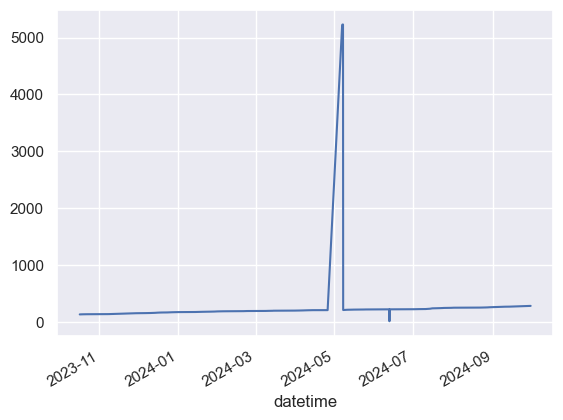

In [24]:
df_met['PCIRZZZ'].where(df_met['station'] == 'PPSA2').plot()

In [25]:
# LIGHT CLEANING
# drop PCIRZZZ values above 1000 
df_met['PCIRZZZ'] = df_met['PCIRZZZ'].where(df_met['PCIRZZZ'] < 1000) # only keep values below 100
df_met['PCIRZZZ'] = df_met['PCIRZZZ'].where(df_met['PCIRZZZ'] > 125) # only keep values above 100

df_met['PPDRZZZ'] = df_met['PPDRZZZ'].where(df_met['PPDRZZZ'] > -1000)
df_met['PPIRZZZ'] = df_met['PPIRZZZ'].where(df_met['PPIRZZZ'] > -1000)
df_met['PPPRZZZ'] = df_met['PPPRZZZ'].where(df_met['PPPRZZZ'] > -1000)
df_met['PPVRZZZ'] = df_met['PPVRZZZ'].where(df_met['PPVRZZZ'] > -1000)

# drop any SDIRZZZ values above 1000, for now 
df_met['SDIRZZZ'] = df_met['SDIRZZZ'].where(df_met['SDIRZZZ'] < 1000)

# CREATE A PP DATASET ONLY 
# create a new dataframe with only PPSA2 station data
df_met_pp = df_met[df_met['station'] == 'PPSA2']
df_met_pp = df_met_pp.dropna(axis=1, how='all')

# calculate precip_rate from precip_accum
df_met_pp['PPIRZZZ'] = df_met_pp['PCIRZZZ'].diff() # subtract the previus value to get the difference 

# then drop any values about 10 
df_met_pp['PPIRZZZ'] = df_met_pp['PPIRZZZ'].where(df_met_pp['PPIRZZZ'] < 1)
df_met_pp


,station,utc_valid,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,PPIRZZZ
datetime,,,,,,,
2023-10-16 18:00:00,PPSA2,2023-10-16 18:00:00,128.62,0.00,49.7,63.04,NaN
2023-10-16 19:00:00,PPSA2,2023-10-16 19:00:00,128.62,0.00,50.5,59.44,0.0
2023-10-16 20:00:00,PPSA2,2023-10-16 20:00:00,128.62,0.00,48.2,72.65,0.0
2023-10-16 21:00:00,PPSA2,2023-10-16 21:00:00,128.62,0.00,48.3,71.85,0.0
2023-10-16 22:00:00,PPSA2,2023-10-16 22:00:00,128.62,0.00,48.4,72.42,0.0
...,...,...,...,...,...,...,...
2024-09-29 20:00:00,PPSA2,2024-09-29 20:00:00,278.46,14.36,40.4,91.40,0.0
2024-09-29 21:00:00,PPSA2,2024-09-29 21:00:00,278.46,16.34,39.9,88.20,0.0
2024-09-29 22:00:00,PPSA2,2024-09-29 22:00:00,278.46,16.56,40.4,88.60,0.0


<Axes: xlabel='datetime'>

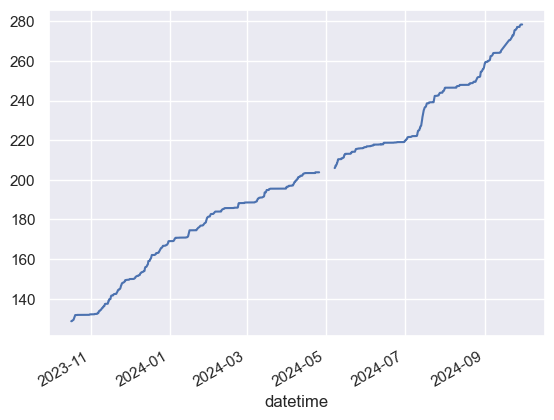

In [26]:
df_met['PCIRZZZ'].where(df_met['station'] == 'PPSA2').plot()

In [27]:
# first save all the hourly datasets so this is easier to read and follow
PC_PPSA2 = (df_met['PCIRZZZ']*25.4).where(df_met['station'] == 'PPSA2').resample('h').mean()
# drop the weird value in PC_PPSA2 which is less than 100 
# PC_PPSA2 = PC_PPSA2.where(PC_PPSA2 > 100)

PC_SDIA2 = (df_met['PCIRZZZ']*25.4).where(df_met['station'] == 'SDIA2').resample('h').mean()
PP_ECEA2 = (df_met['PPIRZZZ']*25.4).where(df_met['station'] == 'ECEA2').resample('h').mean()

# put all of these into a dataset together 
# create an empty pandas dataframe 
df_precip = pd.DataFrame()
df_precip['PC_PPSA2'] = PC_PPSA2.copy()
df_precip['PC_SDIA2'] = PC_SDIA2.copy()
df_precip['PP_ECEA2'] = PP_ECEA2.copy()
df_precip.head() 

,PC_PPSA2,PC_SDIA2,PP_ECEA2
datetime,,,
2023-10-01 00:00:00,NaN,NaN,0.254000
2023-10-01 01:00:00,NaN,NaN,0.423333
2023-10-01 02:00:00,NaN,NaN,0.677333
2023-10-01 03:00:00,NaN,NaN,1.608667
2023-10-01 04:00:00,NaN,NaN,3.302000


<Axes: title={'center': 'Hourly Precipitation at Powder Patch'}, xlabel='datetime'>

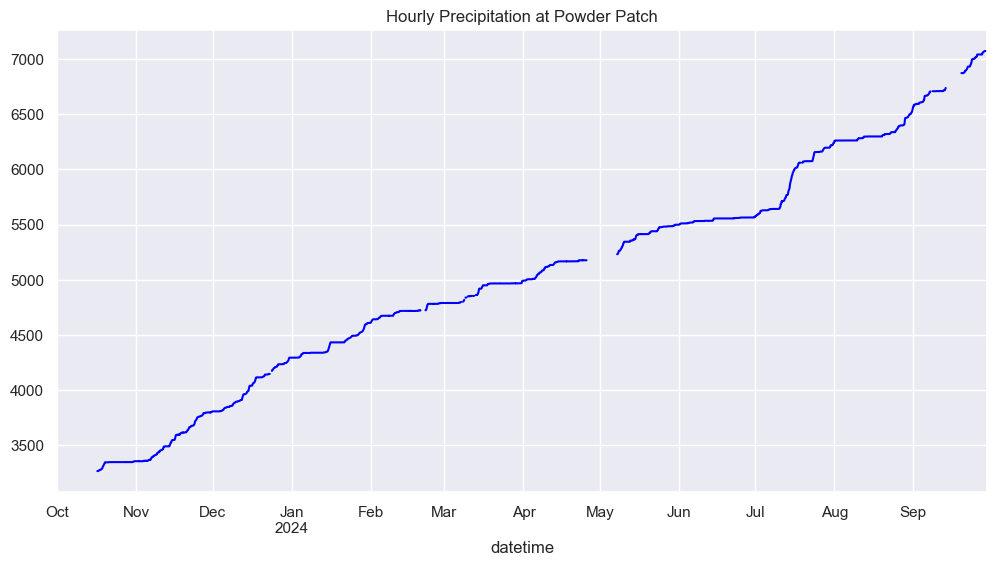

In [28]:
df_precip.PC_PPSA2.plot(label='PC_PPSA2', color='blue', figsize=(12, 6), title='Hourly Precipitation at Powder Patch')

In [29]:
# now calculate the rate from the cumulative precipitation
df_precip['PR_PPSA2'] = df_precip['PC_PPSA2'].diff()  # Calculate the difference to get the rate
df_precip['PR_SDIA2'] = df_precip['PC_SDIA2'].diff()  # Calculate the difference to get the rate,
 
df_precip['PR_ECEA2'] = df_precip['PP_ECEA2'].diff()  # this one is daily accumulation so not sure....
df_precip['PR_ECEA2'] = df_precip['PR_ECEA2'].where(df_precip['PR_ECEA2'] >=0, df_precip['PP_ECEA2'])  # need to handle the daily rests 

# df_precip['PC_ECEA2'] = df_precip['PP_ECEA2'].cumsum()
df_precip['PC_ECEA2'] = df_precip['PR_ECEA2'].cumsum()

df_precip.head()

,PC_PPSA2,PC_SDIA2,PP_ECEA2,PR_PPSA2,PR_SDIA2,PR_ECEA2,PC_ECEA2
datetime,,,,,,,
2023-10-01 00:00:00,NaN,NaN,0.254000,NaN,NaN,0.254000,0.254000
2023-10-01 01:00:00,NaN,NaN,0.423333,NaN,NaN,0.169333,0.423333
2023-10-01 02:00:00,NaN,NaN,0.677333,NaN,NaN,0.254000,0.677333
2023-10-01 03:00:00,NaN,NaN,1.608667,NaN,NaN,0.931333,1.608667
2023-10-01 04:00:00,NaN,NaN,3.302000,NaN,NaN,1.693333,3.302000


In [30]:
# all datasets to the same date range
start_date = '2023-10-01 01:00'
end_date = '2024-02-15 00:00'

# select the date range for all datasets
df_precip = df_precip.loc[start_date:end_date]
ds_f123_pp = ds_f123_pp.sel(time=slice(start_date, end_date))
ds_f567_pp = ds_f567_pp.sel(time=slice(start_date, end_date))
ds_f678_pp = ds_f678_pp.sel(time=slice(start_date, end_date))
ds_f6to29_pp = ds_f6to29_pp.sel(time=slice(start_date, end_date))
ds_f6to11_pp = ds_f6to11_pp.sel(time=slice(start_date, end_date))

# # but also need to make sure they are all the same length with no missing datetimes
# # resample the datasets to hourly frequency
# ds_f123_pp = ds_f123_pp.resample(time='1h').mean()
# ds_f567_pp = ds_f567_pp.resample(time='1h').mean()
# ds_f678_pp = ds_f678_pp.resample(time='1h').mean()
# ds_f6to29_pp = ds_f6to29_pp.resample(time='1h').mean()
# ds_f6to11_pp = ds_f6to11_pp.resample(time='1h').mean()
# # and the precip dataframe to hourly frequency
# df_precip = df_precip.resample('h').mean()

In [31]:
# df_precip['precip_rate_hrrrak_f123'] = ds_f123_pp['precip_total'].values
# df_precip['precip_accu_hrrrak_f123'] = ds_f123_pp['precip_total'].cumsum().values

# df_precip['precip_rate_hrrrak_f567'] = ds_f567_pp['precip_total'].values
# df_precip['precip_accu_hrrrak_f567'] = ds_f567_pp['precip_total'].cumsum().values
# df_precip['precip_rate_hrrrak_f678'] = ds_f678_pp['precip_total'].values
# df_precip['precip_accu_hrrrak_f678'] = ds_f678_pp['precip_total'].cumsum().values
# df_precip['precip_rate_hrrrak_f6to11'] = ds_f6to11_pp['precip_total'].values
# df_precip['precip_accu_hrrrak_f6to11'] = ds_f6to11_pp['precip_total'].cumsum().values
# df_precip['precip_rate_hrrrak_f6to29'] = ds_f6to29_pp['precip_total'].values
# df_precip['precip_accu_hrrrak_f6to29'] = ds_f6to29_pp['precip_total'].cumsum().values

## Plot a few variables,

In [32]:
ds_f567

<xarray.Dataset> Size: 289MB
Dimensions:                  (x: 21, y: 20, time: 3311)
Coordinates:
  * x                        (x) float64 168B 5.039e+05 5.069e+05 ... 5.633e+05
  * y                        (y) float64 160B 6.495e+06 6.492e+06 ... 6.439e+06
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    valid_time               (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB 05:00:00 ... 07:00:00
    boundaryLayerCloudLayer  float64 8B 0.0
    spatial_ref              int64 8B 0
Data variables: (12/52)
    pt                       (time, y, x) float32 6MB 280.5 280.1 ... 276.7
    temp                     (time, y, x) float32 6MB 281.2 277.3 ... 271.7
    d2m                      (time, y, x) float32 6MB 278.3 276.0 ... 255.1
    sh2                      (time, y, x) float32 6MB 0.00543 ... 0.000987
    rh                       (time, y, x) float32 6MB 82.3 88.5 ... 24.2 17.9
    u10                      (time, y, x) float32 6MB -3.785 -3.598 ... -1.788
    ...                       ...
    lai                      (time, y, x) float32 6MB 0.0 1.125 ... 0.25 0.625
    vgtyp                    (time, y, x) float32 6MB 17.0 1.0 1.0 ... 1.0 15.0
    cloud_total              (time, y, x) float32 6MB 48.0 28.0 59.0 ... 0.0 0.0
    cloud_high               (time, y, x) float32 6MB 90.0 99.0 ... 0.0 0.0
    cloud_low                (time, y, x) float32 6MB 100.0 100.0 ... 0.0 0.0
    wind                     (time, y, x) float32 6MB 7.95 5.951 ... 3.506 1.793
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

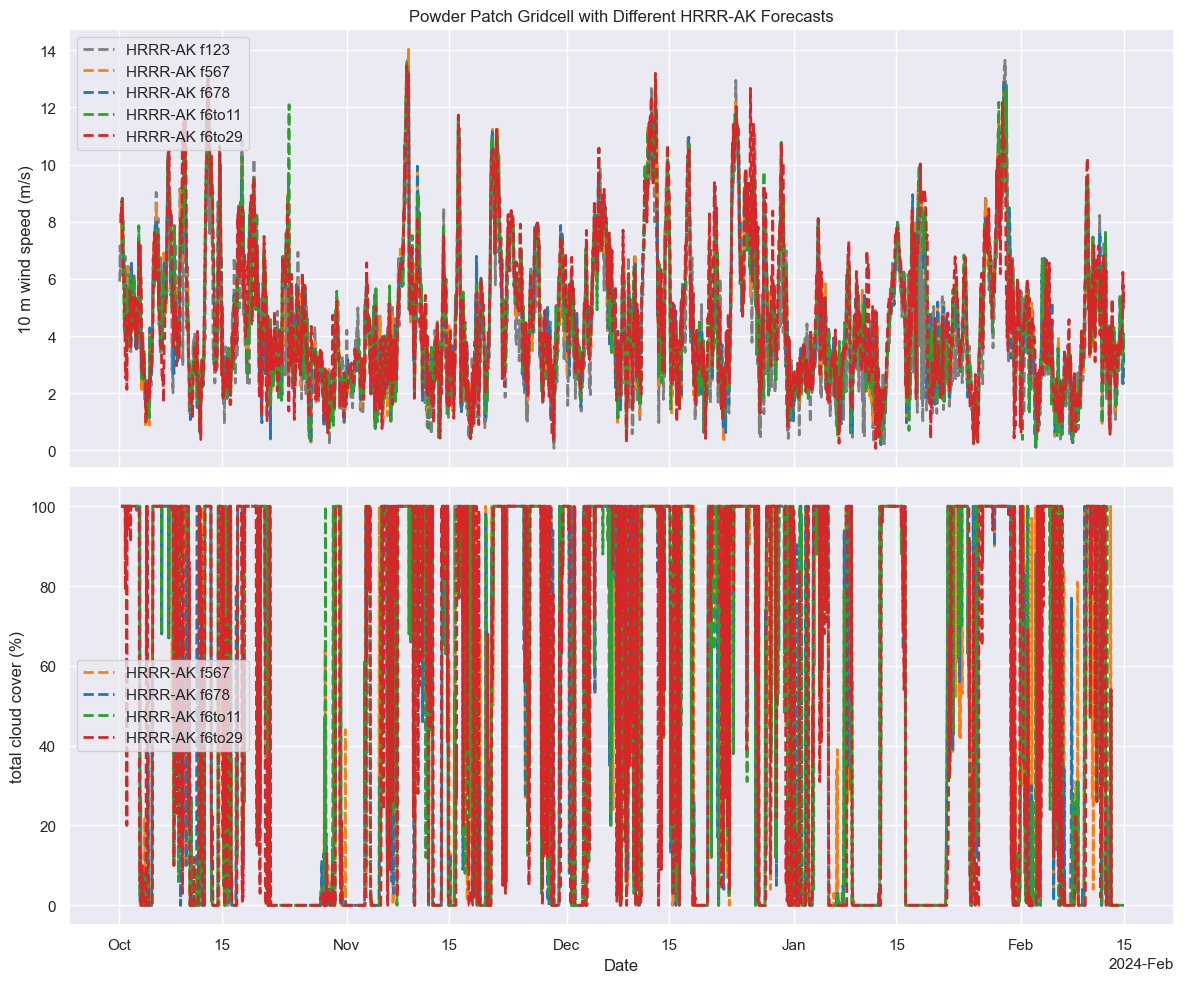

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ds_f123_pp['wind'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
ds_f567_pp['wind'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['wind'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['wind'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['wind'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

# ds_f123_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey') # no cloud cover downloaded for f123
ds_f567_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

ax[0].set_xlabel('')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('10 m wind speed (m/s)')
ax[1].set_ylabel('total cloud cover (%)')
ax[0].set_title('Powder Patch Gridcell with Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()
plt.tight_layout()

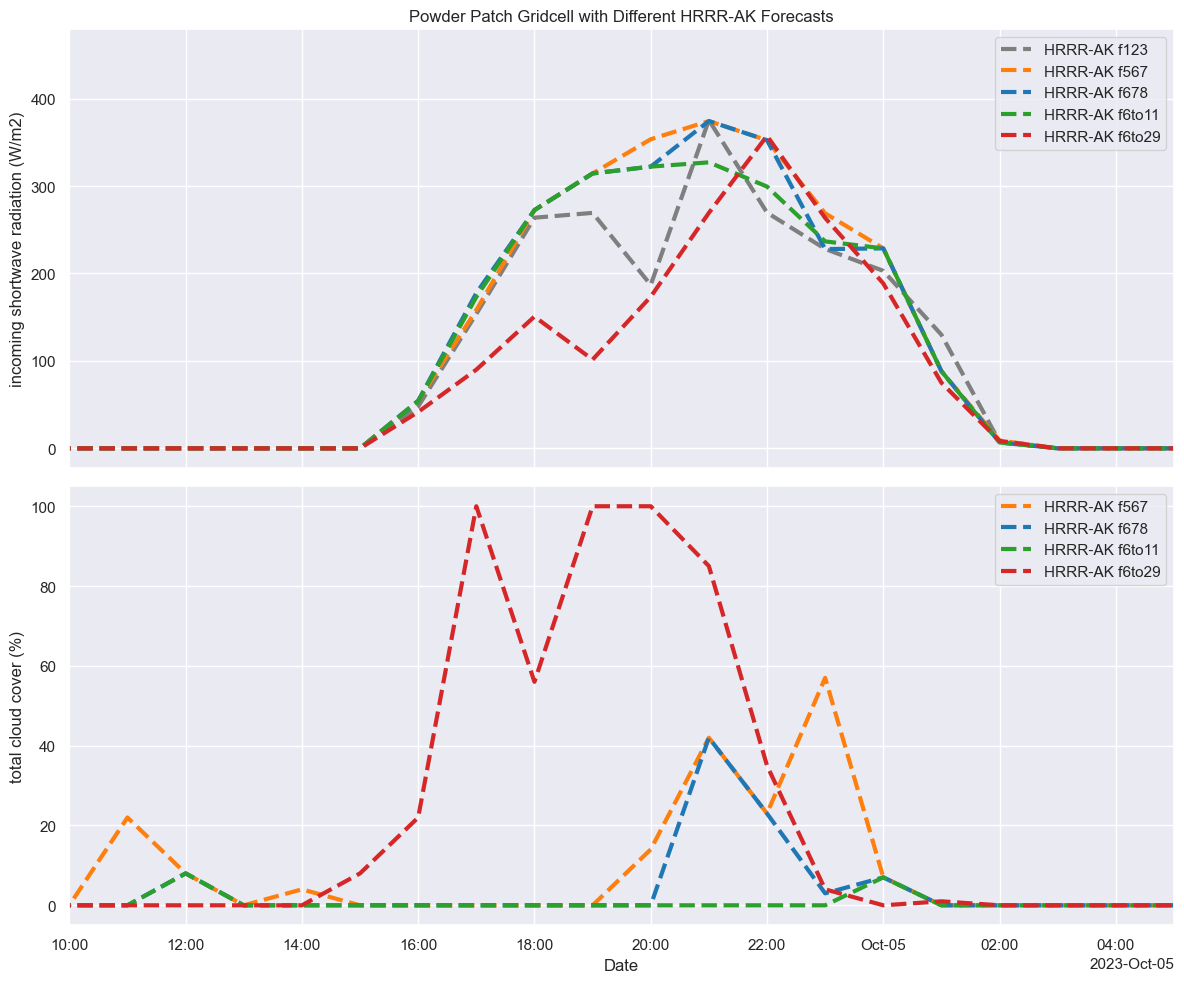

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ds_f123_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

# ds_f123_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey') # no cloud cover downloaded for f123
ds_f567_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['cloud_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ax[0].set_xlabel('')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('incoming shortwave radiation (W/m2)')
ax[1].set_ylabel('total cloud cover (%)')
ax[0].set_title('Powder Patch Gridcell with Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()

# zoom into a single day 
# start_date = '2023-12-20 00:00'
# end_date = '2023-12-29 00:00'
# start_date = '2023-10-04 10:00'
# end_date = '2023-10-07 05:00'
start_date = '2023-10-04 10:00'
end_date = '2023-10-05 05:00'
ax[0].set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))

plt.tight_layout()

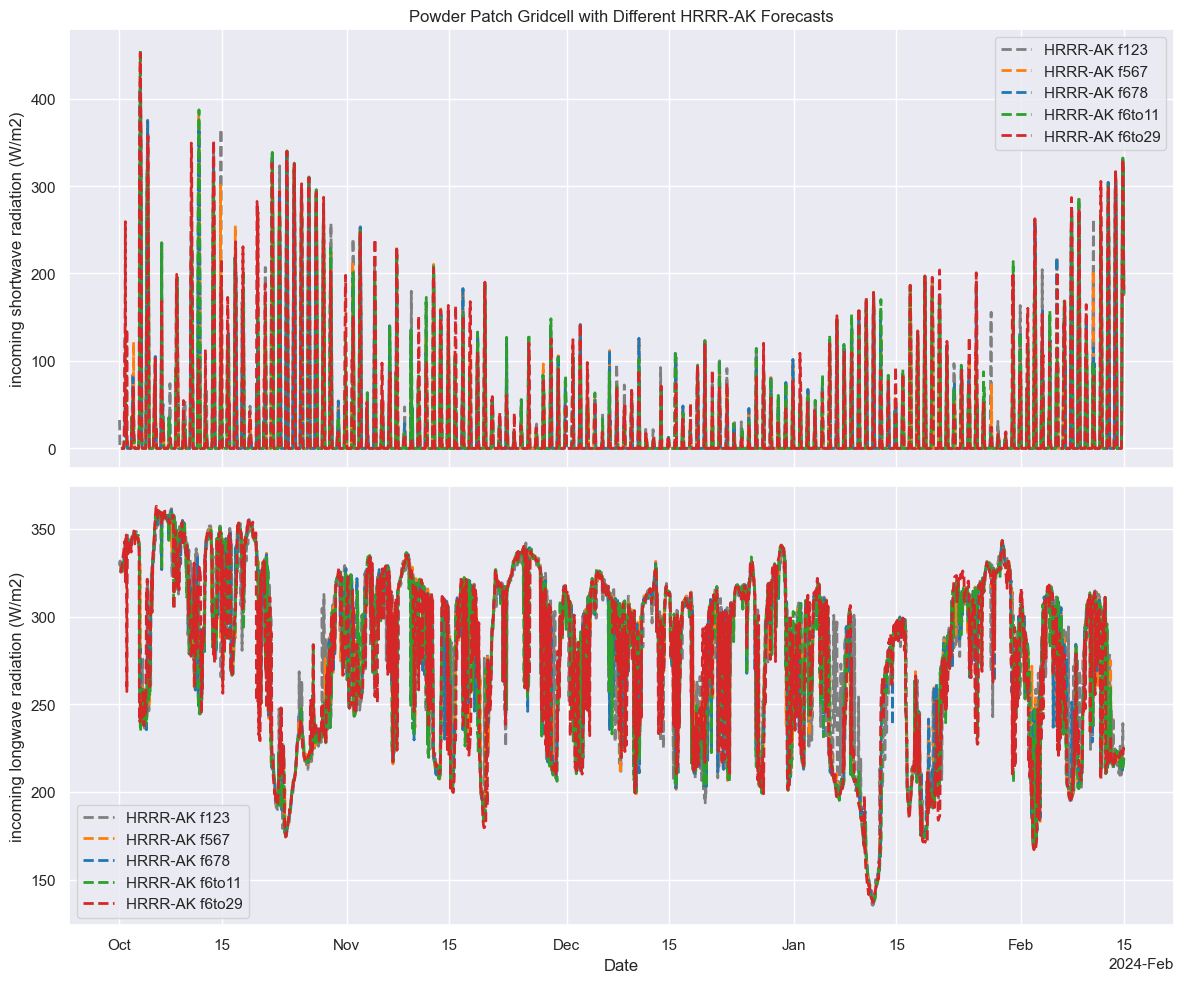

In [35]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ds_f123_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
ds_f567_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['swrad'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

ds_f123_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
ds_f567_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

ax[0].set_xlabel('')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('incoming shortwave radiation (W/m2)')
ax[1].set_ylabel('incoming longwave radiation (W/m2)')
ax[0].set_title('Powder Patch Gridcell with Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()
plt.tight_layout()


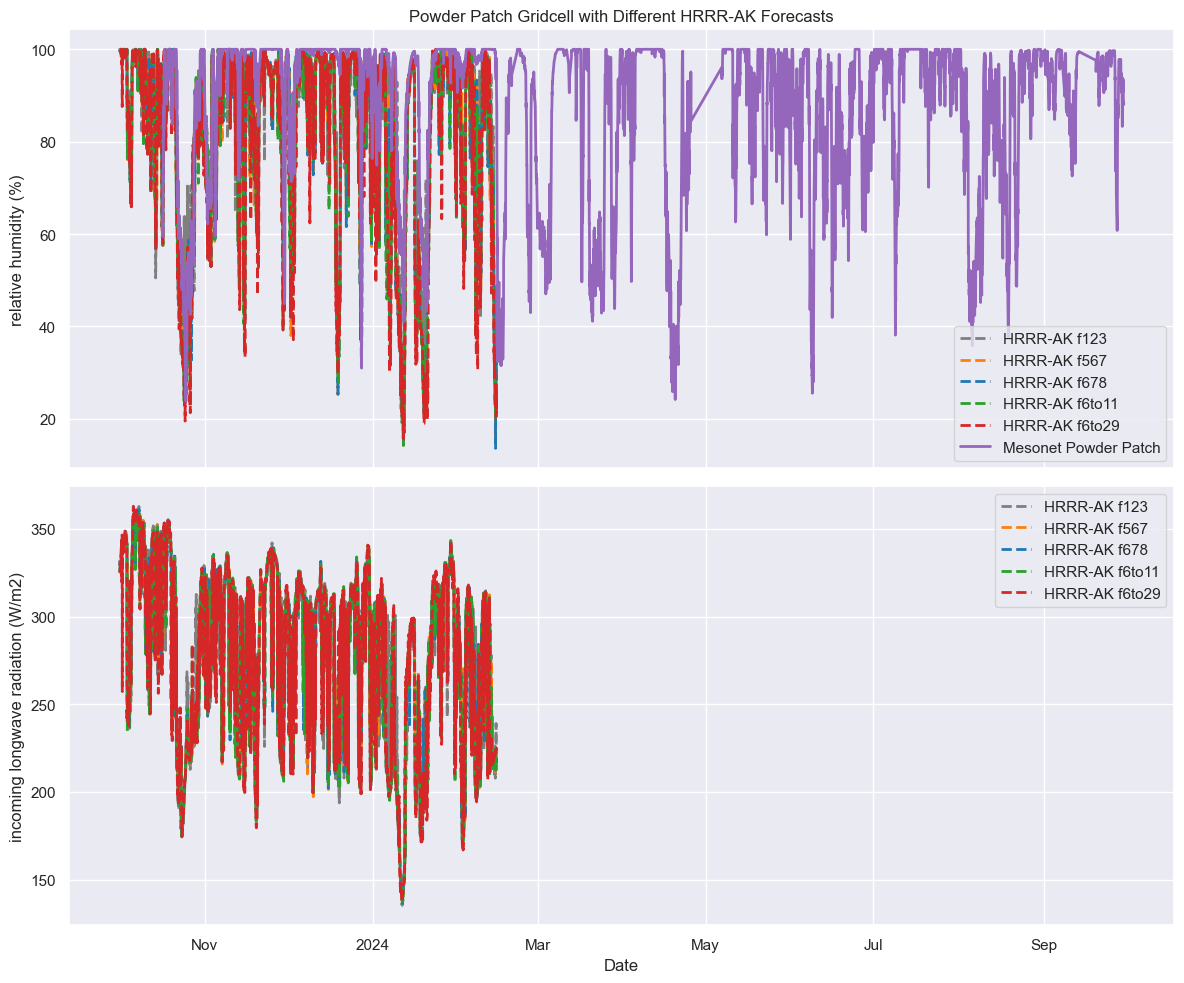

In [36]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ds_f123_pp['rh'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
ds_f567_pp['rh'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['rh'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['rh'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['rh'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

df_met_pp['XRIRZZZ'].plot(ax=ax[0], linestyle='-', label='Mesonet Powder Patch', linewidth=2, color='tab:purple')


ds_f123_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
ds_f567_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
ds_f678_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
ds_f6to11_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
ds_f6to29_pp['lwrad'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

ax[0].set_xlabel('')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('relative humidity (%)')
ax[1].set_ylabel('incoming longwave radiation (W/m2)')
ax[0].set_title('Powder Patch Gridcell with Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()
plt.tight_layout()


In [37]:
df_met_pp['temp_C'] = (df_met_pp['TAIRZZZ'] - 32) * 5/9  # convert from F to C
df_met_pp

,station,utc_valid,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,PPIRZZZ,temp_C
datetime,,,,,,,,
2023-10-16 18:00:00,PPSA2,2023-10-16 18:00:00,128.62,0.00,49.7,63.04,NaN,9.833333
2023-10-16 19:00:00,PPSA2,2023-10-16 19:00:00,128.62,0.00,50.5,59.44,0.0,10.277778
2023-10-16 20:00:00,PPSA2,2023-10-16 20:00:00,128.62,0.00,48.2,72.65,0.0,9.000000
2023-10-16 21:00:00,PPSA2,2023-10-16 21:00:00,128.62,0.00,48.3,71.85,0.0,9.055556
2023-10-16 22:00:00,PPSA2,2023-10-16 22:00:00,128.62,0.00,48.4,72.42,0.0,9.111111
...,...,...,...,...,...,...,...,...
2024-09-29 20:00:00,PPSA2,2024-09-29 20:00:00,278.46,14.36,40.4,91.40,0.0,4.666667
2024-09-29 21:00:00,PPSA2,2024-09-29 21:00:00,278.46,16.34,39.9,88.20,0.0,4.388889
2024-09-29 22:00:00,PPSA2,2024-09-29 22:00:00,278.46,16.56,40.4,88.60,0.0,4.666667


In [38]:
# select only certain dates for df_met_pp
start_date = '2023-10-01 00:00'
end_date = '2024-02-15'
df_met_pp = df_met_pp.loc[start_date:end_date]

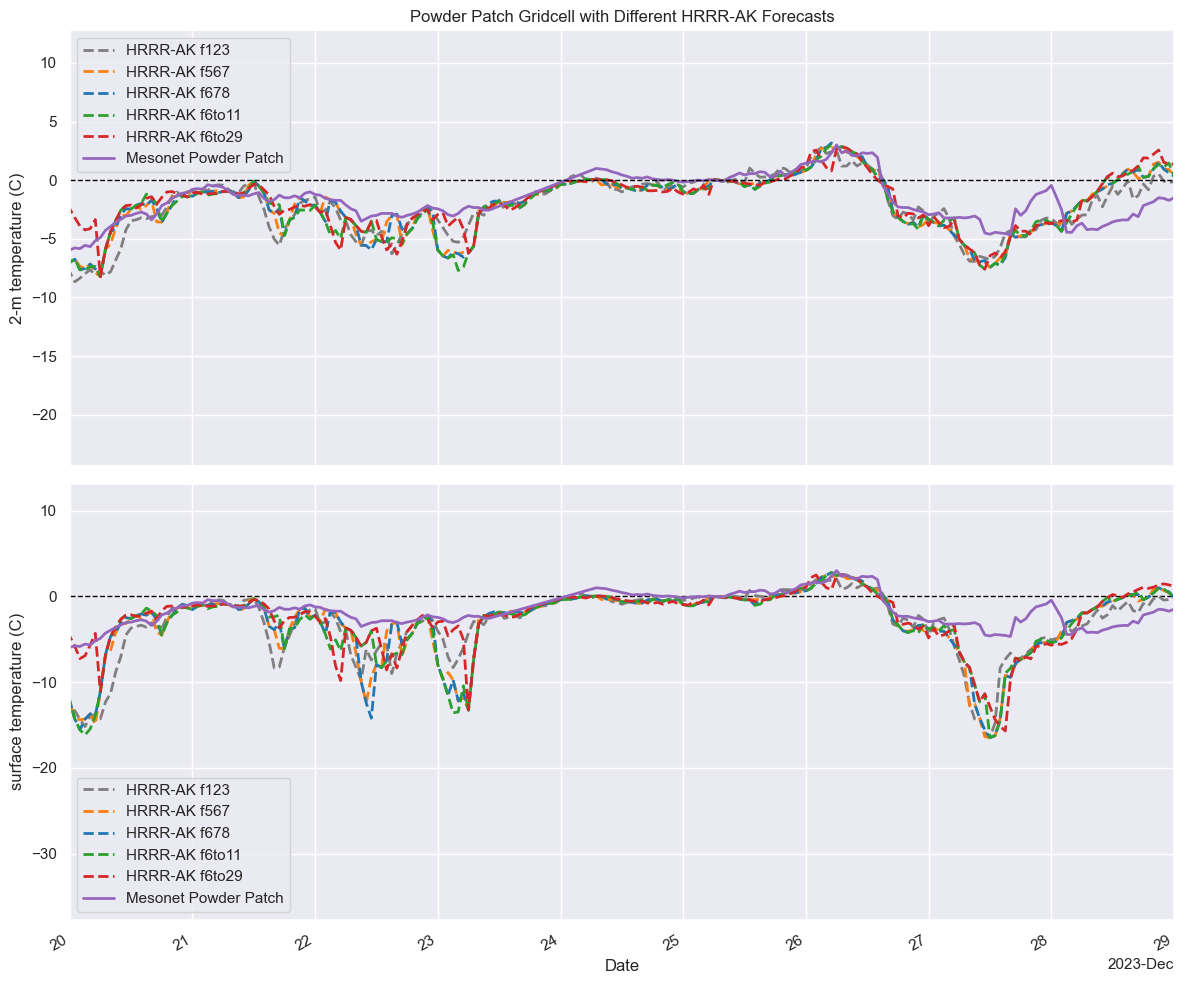

In [57]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

(ds_f123_pp['temp']-273.5).plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
(ds_f567_pp['temp']-273.5).plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
(ds_f678_pp['temp']-273.5).plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
(ds_f6to11_pp['temp']-273.5).plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
(ds_f6to29_pp['temp']-273.5).plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

df_met_pp['temp_C'].plot(ax=ax[0], linestyle='-', label='Mesonet Powder Patch', linewidth=2, color='tab:purple')

# plot a zero line 
ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
ax[1].axhline(0, color='black', linestyle='--', linewidth=1)

(ds_f123_pp['temp_surface']-273.5).plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=2, color='tab:grey')
(ds_f567_pp['temp_surface']-273.5).plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=2, color='tab:orange')
(ds_f678_pp['temp_surface']-273.5).plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=2, color='tab:blue')
(ds_f6to11_pp['temp_surface']-273.5).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=2, color='tab:green')
(ds_f6to29_pp['temp_surface']-273.5).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=2, color='tab:red')

df_met_pp['temp_C'].plot(ax=ax[1], linestyle='-', label='Mesonet Powder Patch', linewidth=2, color='tab:purple')


ax[0].set_xlabel('')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('2-m temperature (C)')
ax[1].set_ylabel('surface temperature (C)')
ax[0].set_title('Powder Patch Gridcell with Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()

# zoom into a single day 
start_date = '2023-12-20 00:00'
end_date = '2023-12-29 00:00'
# start_date = '2023-12-01 00:00'
# end_date = '2023-12-24 00:00'
ax[0].set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))

# # set y lim 
# ax[0].set_ylim(-5,5)
# ax[1].set_ylim(-5,5)

plt.tight_layout()

Let's look at the different preicpitation variables to understand what they are...

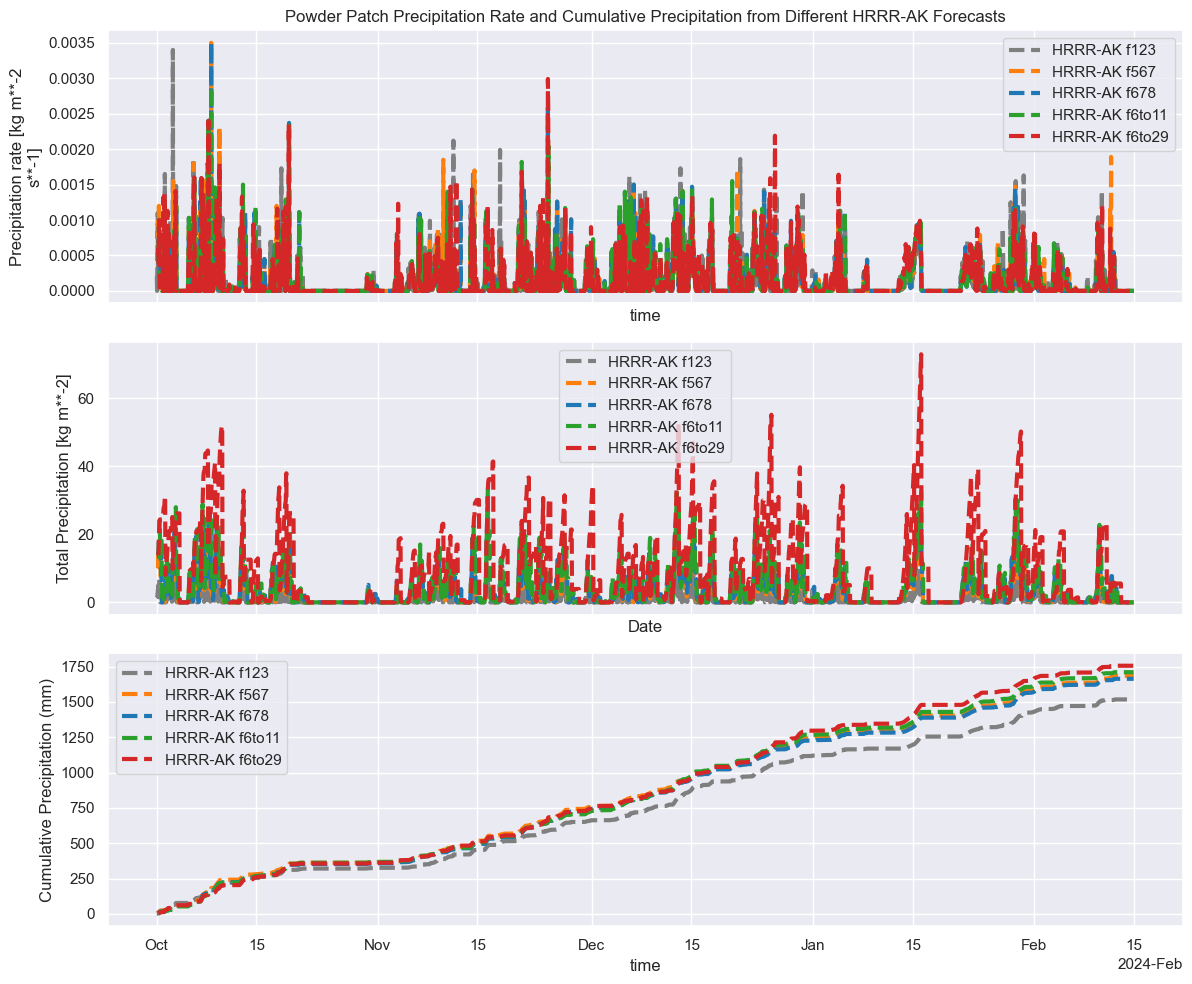

In [46]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ds_f123_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ds_f123_pp['precip_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_total'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

(ds_f123_pp['precip_rate'].cumsum()*3600).plot(ax=ax[2], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
(ds_f567_pp['precip_rate'].cumsum()*3600).plot(ax=ax[2], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
(ds_f678_pp['precip_rate'].cumsum()*3600).plot(ax=ax[2], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
(ds_f6to11_pp['precip_rate'].cumsum()*3600).plot(ax=ax[2], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
(ds_f6to29_pp['precip_rate'].cumsum()*3600).plot(ax=ax[2], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ax[1].set_xlabel('Date')
# ax[0].set_ylabel('Precipitation Rate (mm/hr)')
# ax[1].set_ylabel('Precipitation Rate (mm/hr)')
ax[2].set_ylabel('Cumulative Precipitation (mm)')
ax[0].set_title('Powder Patch Precipitation Rate and Cumulative Precipitation from Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[2].set_title('')
ax[0].legend()
ax[1].legend()
ax[2].legend()

# zoom into a single day 
# start_date = '2023-12-20 00:00'
# end_date = '2023-12-29 00:00'
# start_date = '2023-12-20 00:00'
# end_date = '2023-12-24 00:00'
# ax[0].set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))

plt.tight_layout()

In [47]:
# calculate cumulative preciptiation 
ds_f123_pp['precip_accum'] = ds_f123_pp['precip_rate'].cumsum()*3600
ds_f567_pp['precip_accum'] = ds_f567_pp['precip_rate'].cumsum()*3600
ds_f678_pp['precip_accum'] = ds_f678_pp['precip_rate'].cumsum()*3600
ds_f6to11_pp['precip_accum'] = ds_f6to11_pp['precip_rate'].cumsum()*3600
ds_f6to29_pp['precip_accum'] = ds_f6to29_pp['precip_rate'].cumsum()*3600

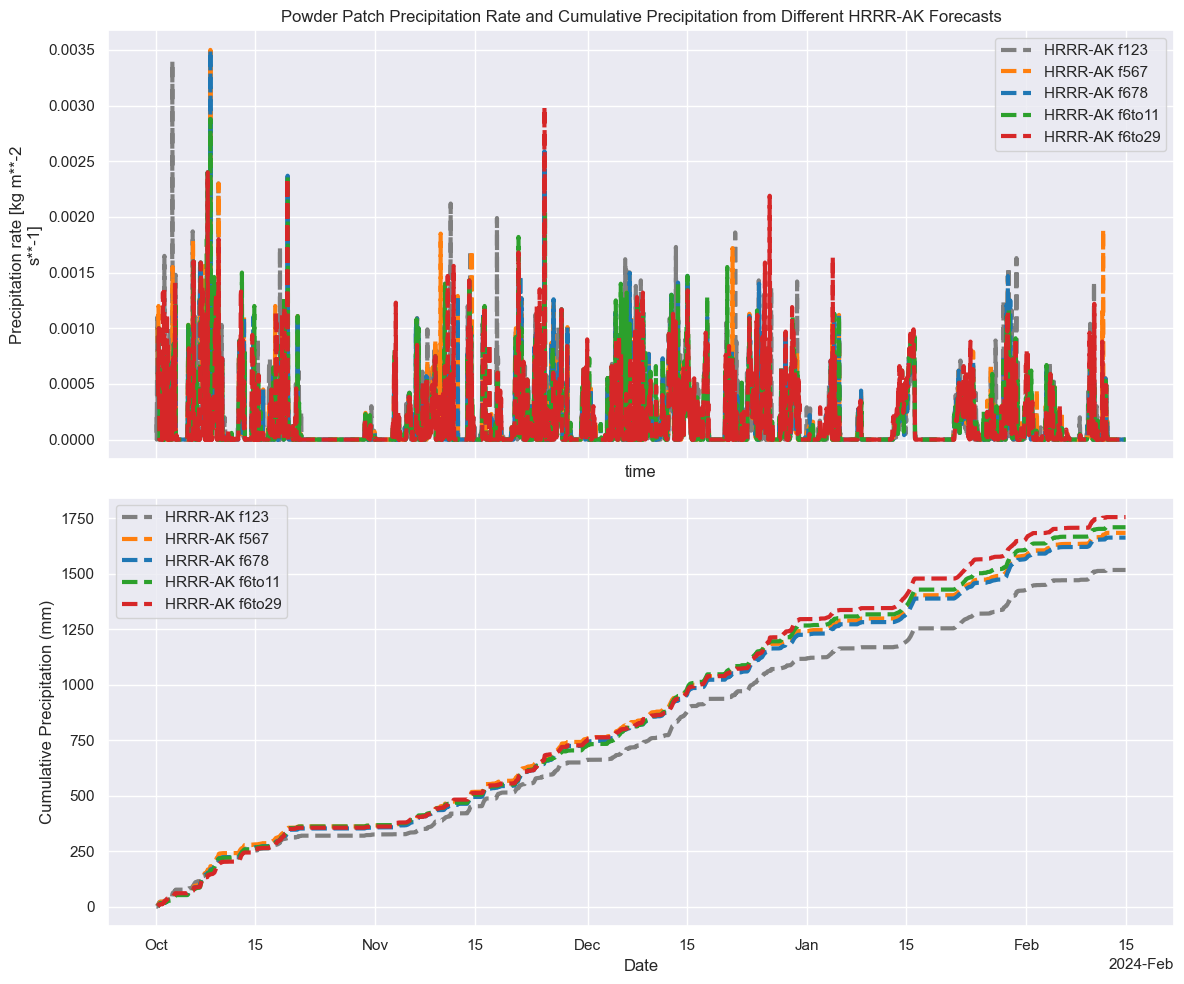

In [48]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ds_f123_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ds_f123_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ax[1].set_xlabel('Date')
# ax[0].set_ylabel('Precipitation Rate (mm/hr)')
ax[1].set_ylabel('Cumulative Precipitation (mm)')
ax[0].set_title('Powder Patch Precipitation Rate and Cumulative Precipitation from Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()
plt.tight_layout()


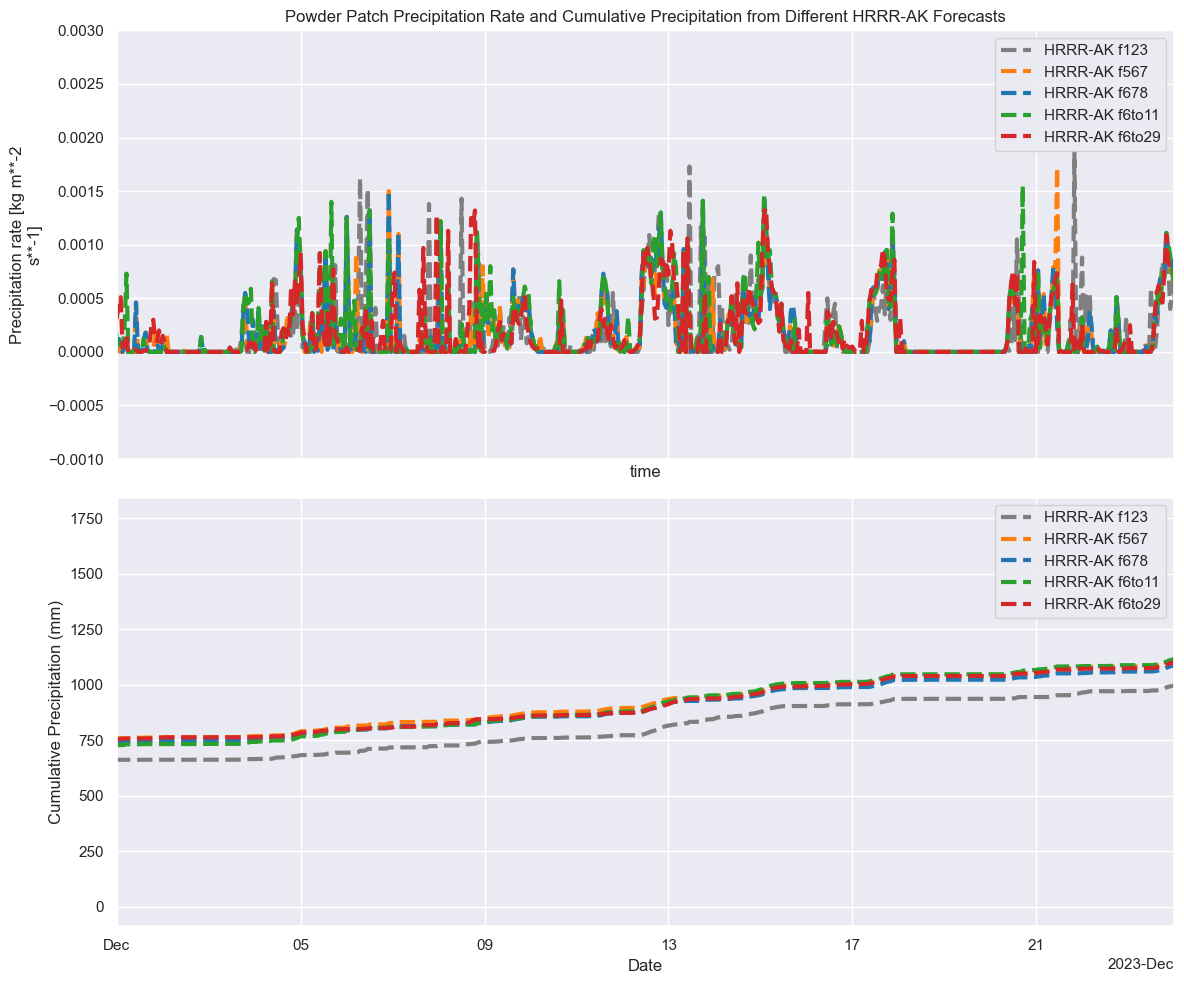

In [49]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ds_f123_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

# (df_met_pp['PCIRZZZ'].diff()*(1/3600)*25.4).plot(ax=ax[0], linestyle='-', label='Mesonet Powder Patch', linewidth=3, color='tab:purple')

ds_f123_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_accum'].plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ax[1].set_xlabel('Date')
# ax[0].set_ylabel('Precipitation Rate (mm/hr)')
ax[1].set_ylabel('Cumulative Precipitation (mm)')
ax[0].set_title('Powder Patch Precipitation Rate and Cumulative Precipitation from Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()

# start_date = '2023-10-01'
# end_date = '2024-02-15'
start_date = '2023-12-01'
end_date = '2023-12-24'
ax[0].set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))

ax[0].set_ylim(-0.001,0.003)

plt.tight_layout()

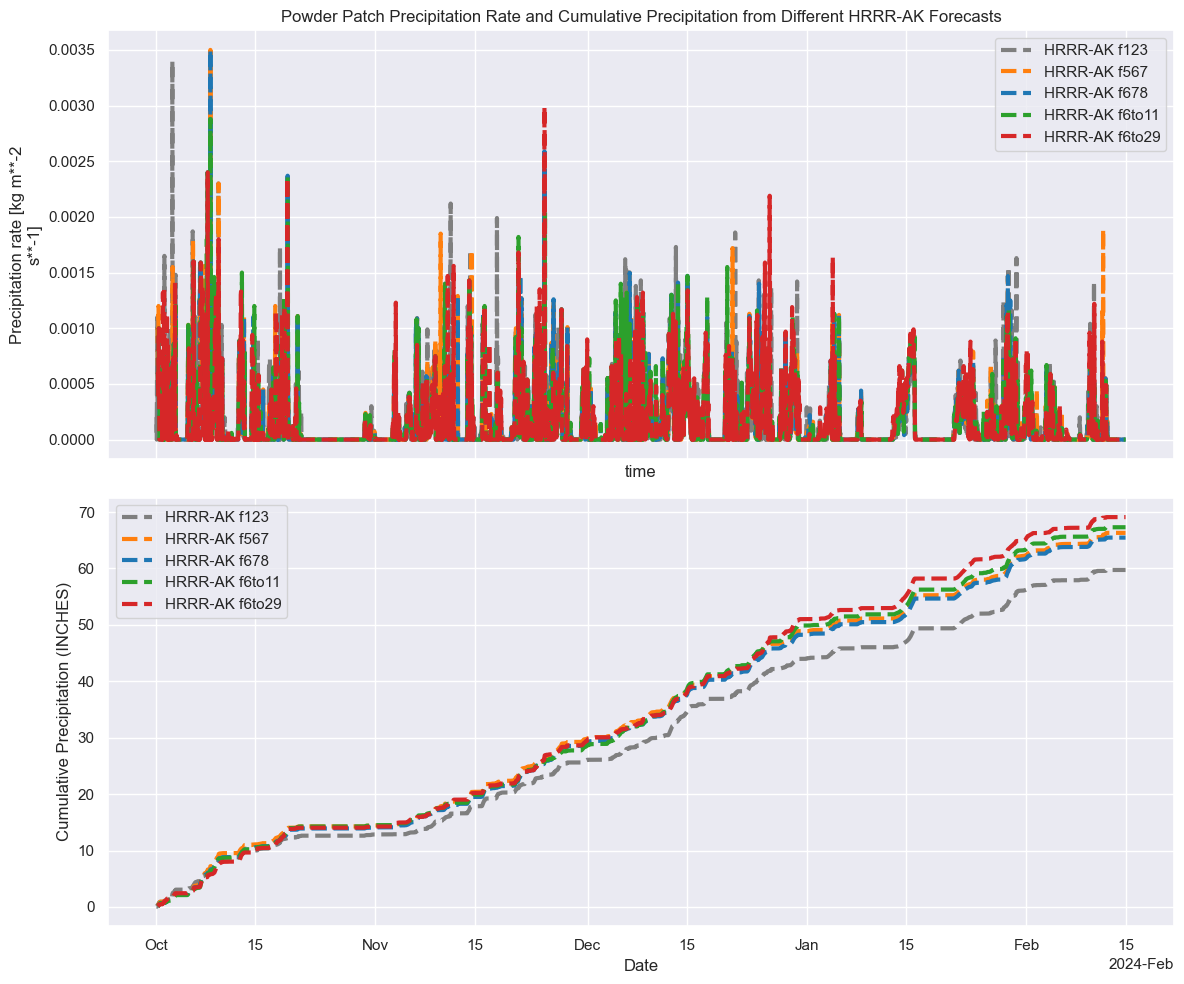

In [50]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ds_f123_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

# convert to inches 
num = 0.0393701 # conversion factor from mm to inches
(ds_f123_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
(ds_f567_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
(ds_f678_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
(ds_f6to11_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
(ds_f6to29_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

ax[1].set_xlabel('Date')
# ax[0].set_ylabel('Precipitation Rate (mm/hr)')
ax[1].set_ylabel('Cumulative Precipitation (INCHES)')
ax[0].set_title('Powder Patch Precipitation Rate and Cumulative Precipitation from Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()

plt.tight_layout()

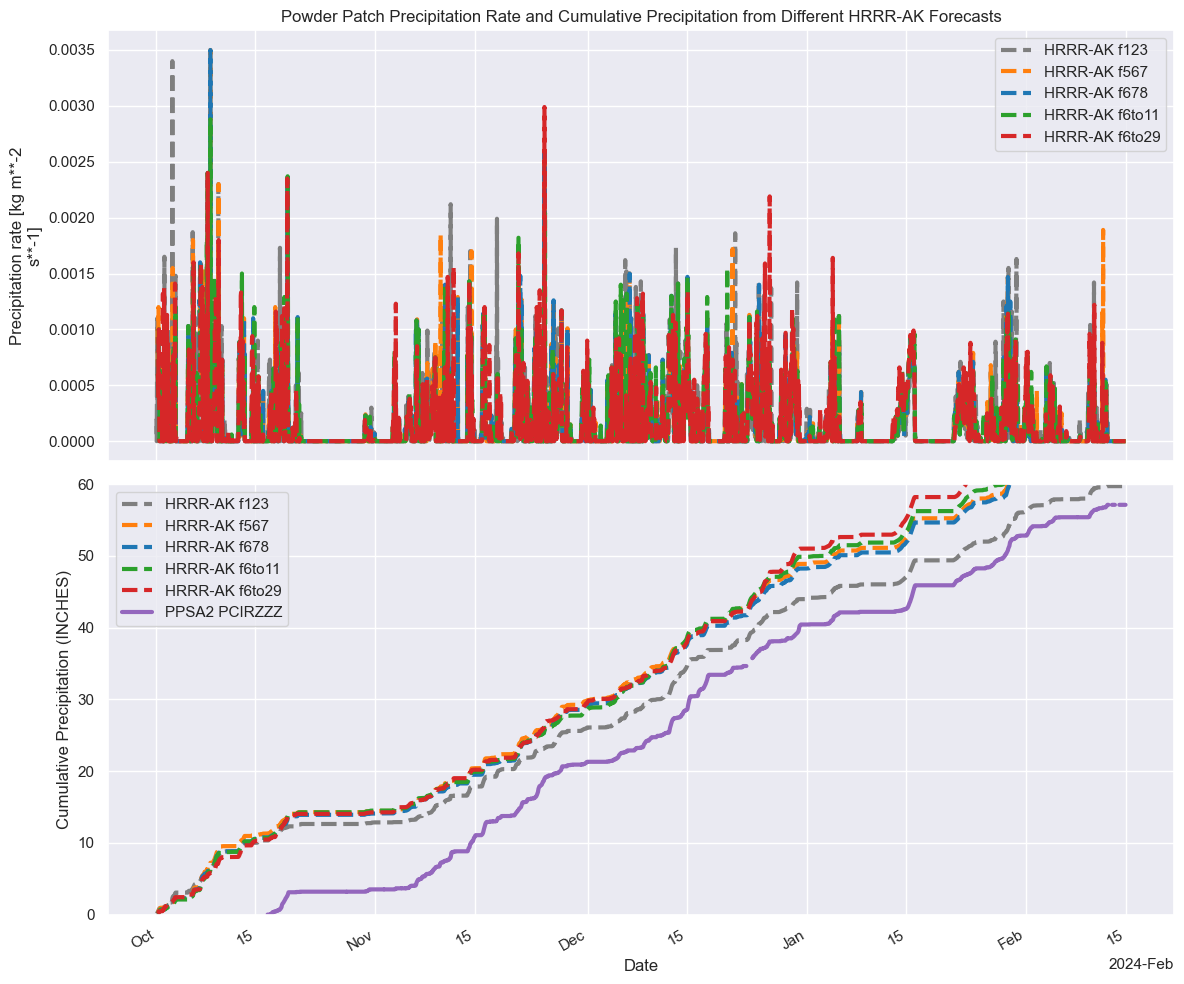

In [56]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ds_f123_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
ds_f567_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
ds_f678_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
ds_f6to11_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
ds_f6to29_pp['precip_rate'].plot(ax=ax[0], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

# convert to inches 
num = 0.0393701 # conversion factor from mm to inches
(ds_f123_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f123', linewidth=3, color='tab:grey')
(ds_f567_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f567', linewidth=3, color='tab:orange')
(ds_f678_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f678', linewidth=3, color='tab:blue')
(ds_f6to11_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to11', linewidth=3, color='tab:green')
(ds_f6to29_pp['precip_accum']*num).plot(ax=ax[1], linestyle='--', label='HRRR-AK f6to29', linewidth=3, color='tab:red')

# df_met['PCIRZZZ'].where(df_met['station'] == 'PPSA2').plot(ax=ax[1], linestyle='-', label='PPSA2 PCIRZZZ', linewidth=3, color='tab:purple')
(df_precip['PC_PPSA2']*num).plot(ax=ax[1], linestyle='-', label='PPSA2 PCIRZZZ', linewidth=3, color='tab:purple')

ax[1].set_xlabel('Date')
# ax[0].set_ylabel('Precipitation Rate (mm/hr)')
ax[1].set_ylabel('Cumulative Precipitation (INCHES)')
ax[0].set_title('Powder Patch Precipitation Rate and Cumulative Precipitation from Different HRRR-AK Forecasts')
ax[1].set_title('')
ax[0].legend()
ax[1].legend()

# start_date = '2023-10-01'
# end_date = '2024-02-15'
# ax[0].set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))

# zoom into the yaxis of the second plot 
ax[1].set_ylim(0, 60)  # Adjust the y-axis limits as needed

plt.tight_layout()

<Axes: xlabel='datetime'>

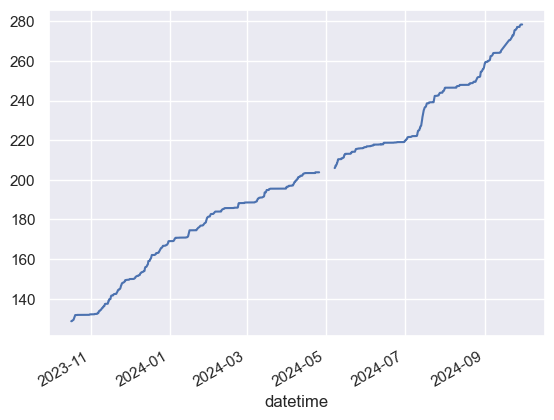

In [52]:
df_met['PCIRZZZ'].where(df_met['station'] == 'PPSA2').plot()

(0.0, 49.0)

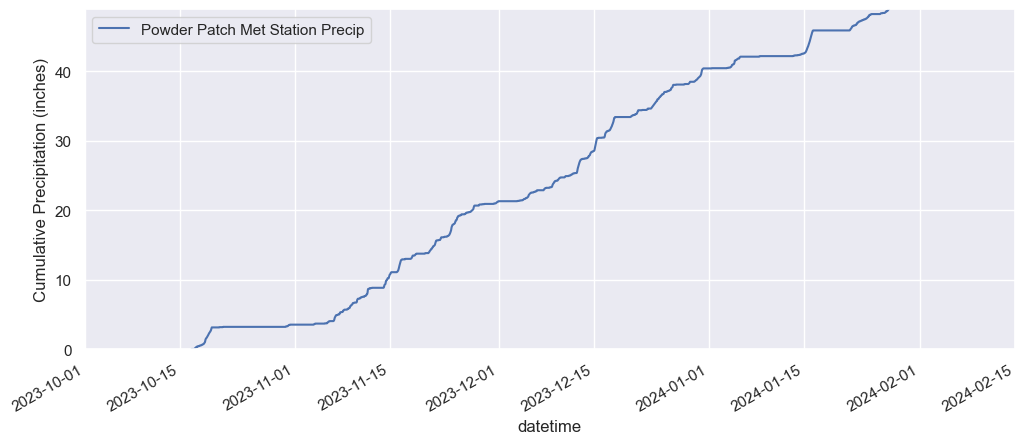

In [53]:
precip_plot = df_met['PCIRZZZ'].where(df_met['station'] == 'PPSA2')
precip_plot = precip_plot - precip_plot.min()
precip_plot.plot(figsize=(12, 5), label='Powder Patch Met Station Precip')

start_date = '2023-10-01'
end_date = '2024-02-15'
plt.xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))
plt.ylabel('Cumulative Precipitation (inches)')
plt.legend()
plt.ylim(0,49)

<Axes: title={'center': 'Hourly Precipitation at Powder Patch'}, xlabel='datetime'>

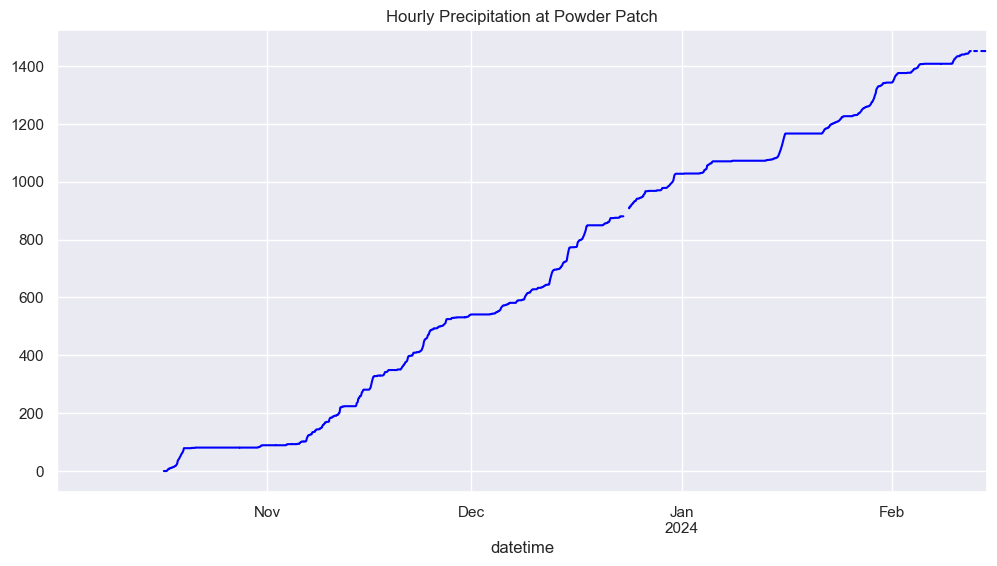

In [54]:
df_precip['PC_PPSA2'].plot(label='PC_PPSA2', color='blue', figsize=(12, 6), title='Hourly Precipitation at Powder Patch')

<Axes: title={'center': 'Hourly Precipitation at Powder Patch'}, xlabel='datetime'>

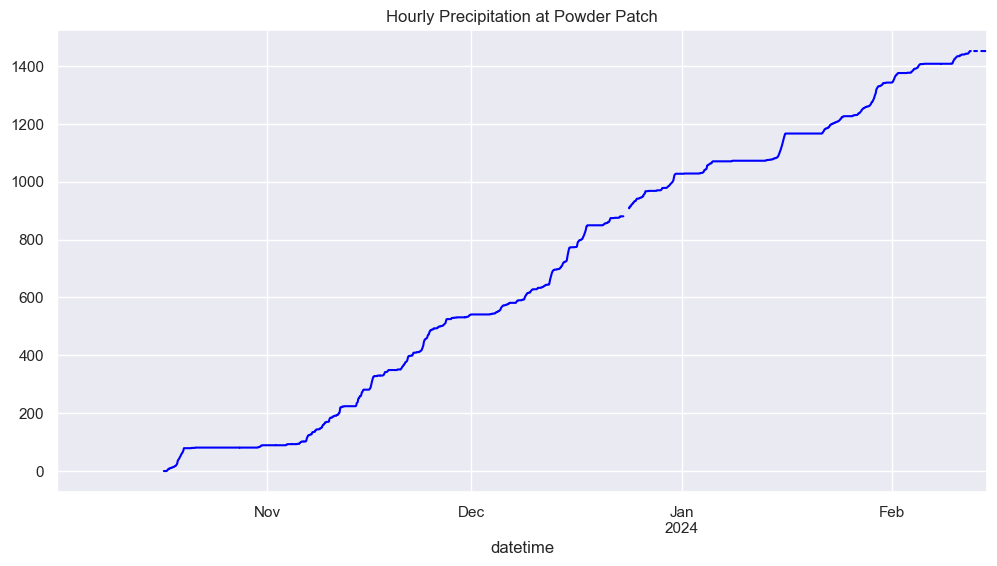

In [55]:
#subtract the smallest value from the cumulative precipitation to make it start at 0
df_precip['PC_PPSA2'] = df_precip['PC_PPSA2'] - df_precip['PC_PPSA2'].min()
df_precip['PC_PPSA2'].plot(label='PC_PPSA2', color='blue', figsize=(12, 6), title='Hourly Precipitation at Powder Patch')

## LOAD 2025